# The Complete 7-Attribute WLS Signature with Background Classification
This notebook generates the actual `Hash Signature` for every single day, and shades the background of the charts to help you visually comprehend exactly what the math is doing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, glob
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

# --- CONFIGURATION ---
DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
LOOKBACK_SHORT = 13
LOOKBACK_LONG = 54
NORMALIZATION_WINDOW = 200
ACCEL_LOOKBACK = 3
PLOT_START = '2023-01-01'
PLOT_END = '2023-06-30' # Extended to 6 months to see more background changes
WARMUP_DAYS = NORMALIZATION_WINDOW + LOOKBACK_LONG

In [2]:
# --- MATH FUNCTIONS ---
def calc_wls_full(series, window):
    reg_line_values = np.full(len(series), np.nan)
    slopes = np.full(len(series), np.nan)
    std_errors = np.full(len(series), np.nan)
    r_squared = np.full(len(series), np.nan)
    z_scores = np.full(len(series), np.nan)
    
    x = np.arange(window)
    w = np.arange(1, window + 1)
    sum_w = np.sum(w)
    
    for i in range(window - 1, len(series)):
        y = series.iloc[i - window + 1 : i + 1].values
        w_mean_x = np.sum(w * x) / sum_w
        w_mean_y = np.sum(w * y) / sum_w
        
        cov = np.sum(w * (x - w_mean_x) * (y - w_mean_y))
        var_x = np.sum(w * (x - w_mean_x)**2)
        slope = cov / var_x if var_x != 0 else 0
        intercept = w_mean_y - slope * w_mean_x
        
        predictions = slope * x + intercept
        residuals = y - predictions
        mse = np.sum(w * residuals**2) / sum_w
        se = np.sqrt(mse)
        
        sst = np.sum(w * (y - w_mean_y)**2) / sum_w 
        r2 = max(0, min(1, 1 - (mse / sst))) if sst != 0 else 0
        
        reg_val = (slope * (window - 1)) + intercept
        reg_line_values[i] = reg_val
        slopes[i] = (slope / w_mean_y) * 252 * 100
        std_errors[i] = (se / w_mean_y) * 100
        r_squared[i] = r2
        z_scores[i] = (y[-1] - reg_val) / se if se != 0 else 0
        
    return pd.Series(reg_line_values, index=series.index), pd.Series(slopes, index=series.index), \
           pd.Series(std_errors, index=series.index), pd.Series(r_squared, index=series.index), pd.Series(z_scores, index=series.index)

def rolling_minmax(series, window):
    roll_min = series.rolling(window).min()
    roll_max = series.rolling(window).max()
    return ((series - roll_min) / (roll_max - roll_min)) * 100

# --- THE CLASSIFIER ENGINE ---
def generate_hash(row):
    if pd.isna(row['slope_13']): return "No_Data"
    
    # 1. Micro Direction & Accel
    mic_d = "UP13" if row['slope_13'] > 0 else "DN13"
    mic_a = "(ris)" if row['accel_13'] > 0 else "(dec)"
    
    # 2. Macro Direction & Accel
    mac_d = "UP54" if row['slope_54'] > 0 else "DN54"
    mac_a = "(ris)" if row['accel_54'] > 0 else "(dec)"
    
    # 3. Momentum
    mom = "fast" if row['slope_13_norm'] > 80 else "slow" if row['slope_13_norm'] < 20 else "base"
    
    # 4. Volatility
    vol = "wide" if row['vol_13'] > 40 else "coil" if row['vol_13'] < 20 else "norm"
    
    # 5. Noise
    noise = "chop" if row['se_13'] > 3.0 else "clean"
    
    # 6. Consistency & Accel
    con = "steady" if row['r2_13'] > 0.6 else "erratic"
    con_a = "(ris)" if row['r2_accel'] > 0 else "(dec)"
    
    # 7. Extension
    z = row['z_13']
    ext = "ext" if abs(z) >= 2 else "rest" if abs(z) <= 0.5 else "mid"
    
    return f"[{mic_d}{mic_a}-{mac_d}{mac_a}-{mom}-{vol}-{noise}-{con}{con_a}-{ext}]"

def assign_regime_color(hash_str):
    # We will shade the background based on Macro Context to make it readable.
    if pd.isna(hash_str) or hash_str == "No_Data": return 'black'
    
    if "UP54(ris)" in hash_str and "UP13" in hash_str:
        return '#003300' # Dark Green: Bullish Acceleration (Full Go)
    elif "UP54" in hash_str and "DN13" in hash_str:
        return '#333300' # Dark Yellow: Bullish Pullback (Resting / Coiling)
    elif "DN54(ris)" in hash_str or "DN54(dec)" in hash_str:
        return '#330000' # Dark Red: Bear Market Regime
    return 'black'


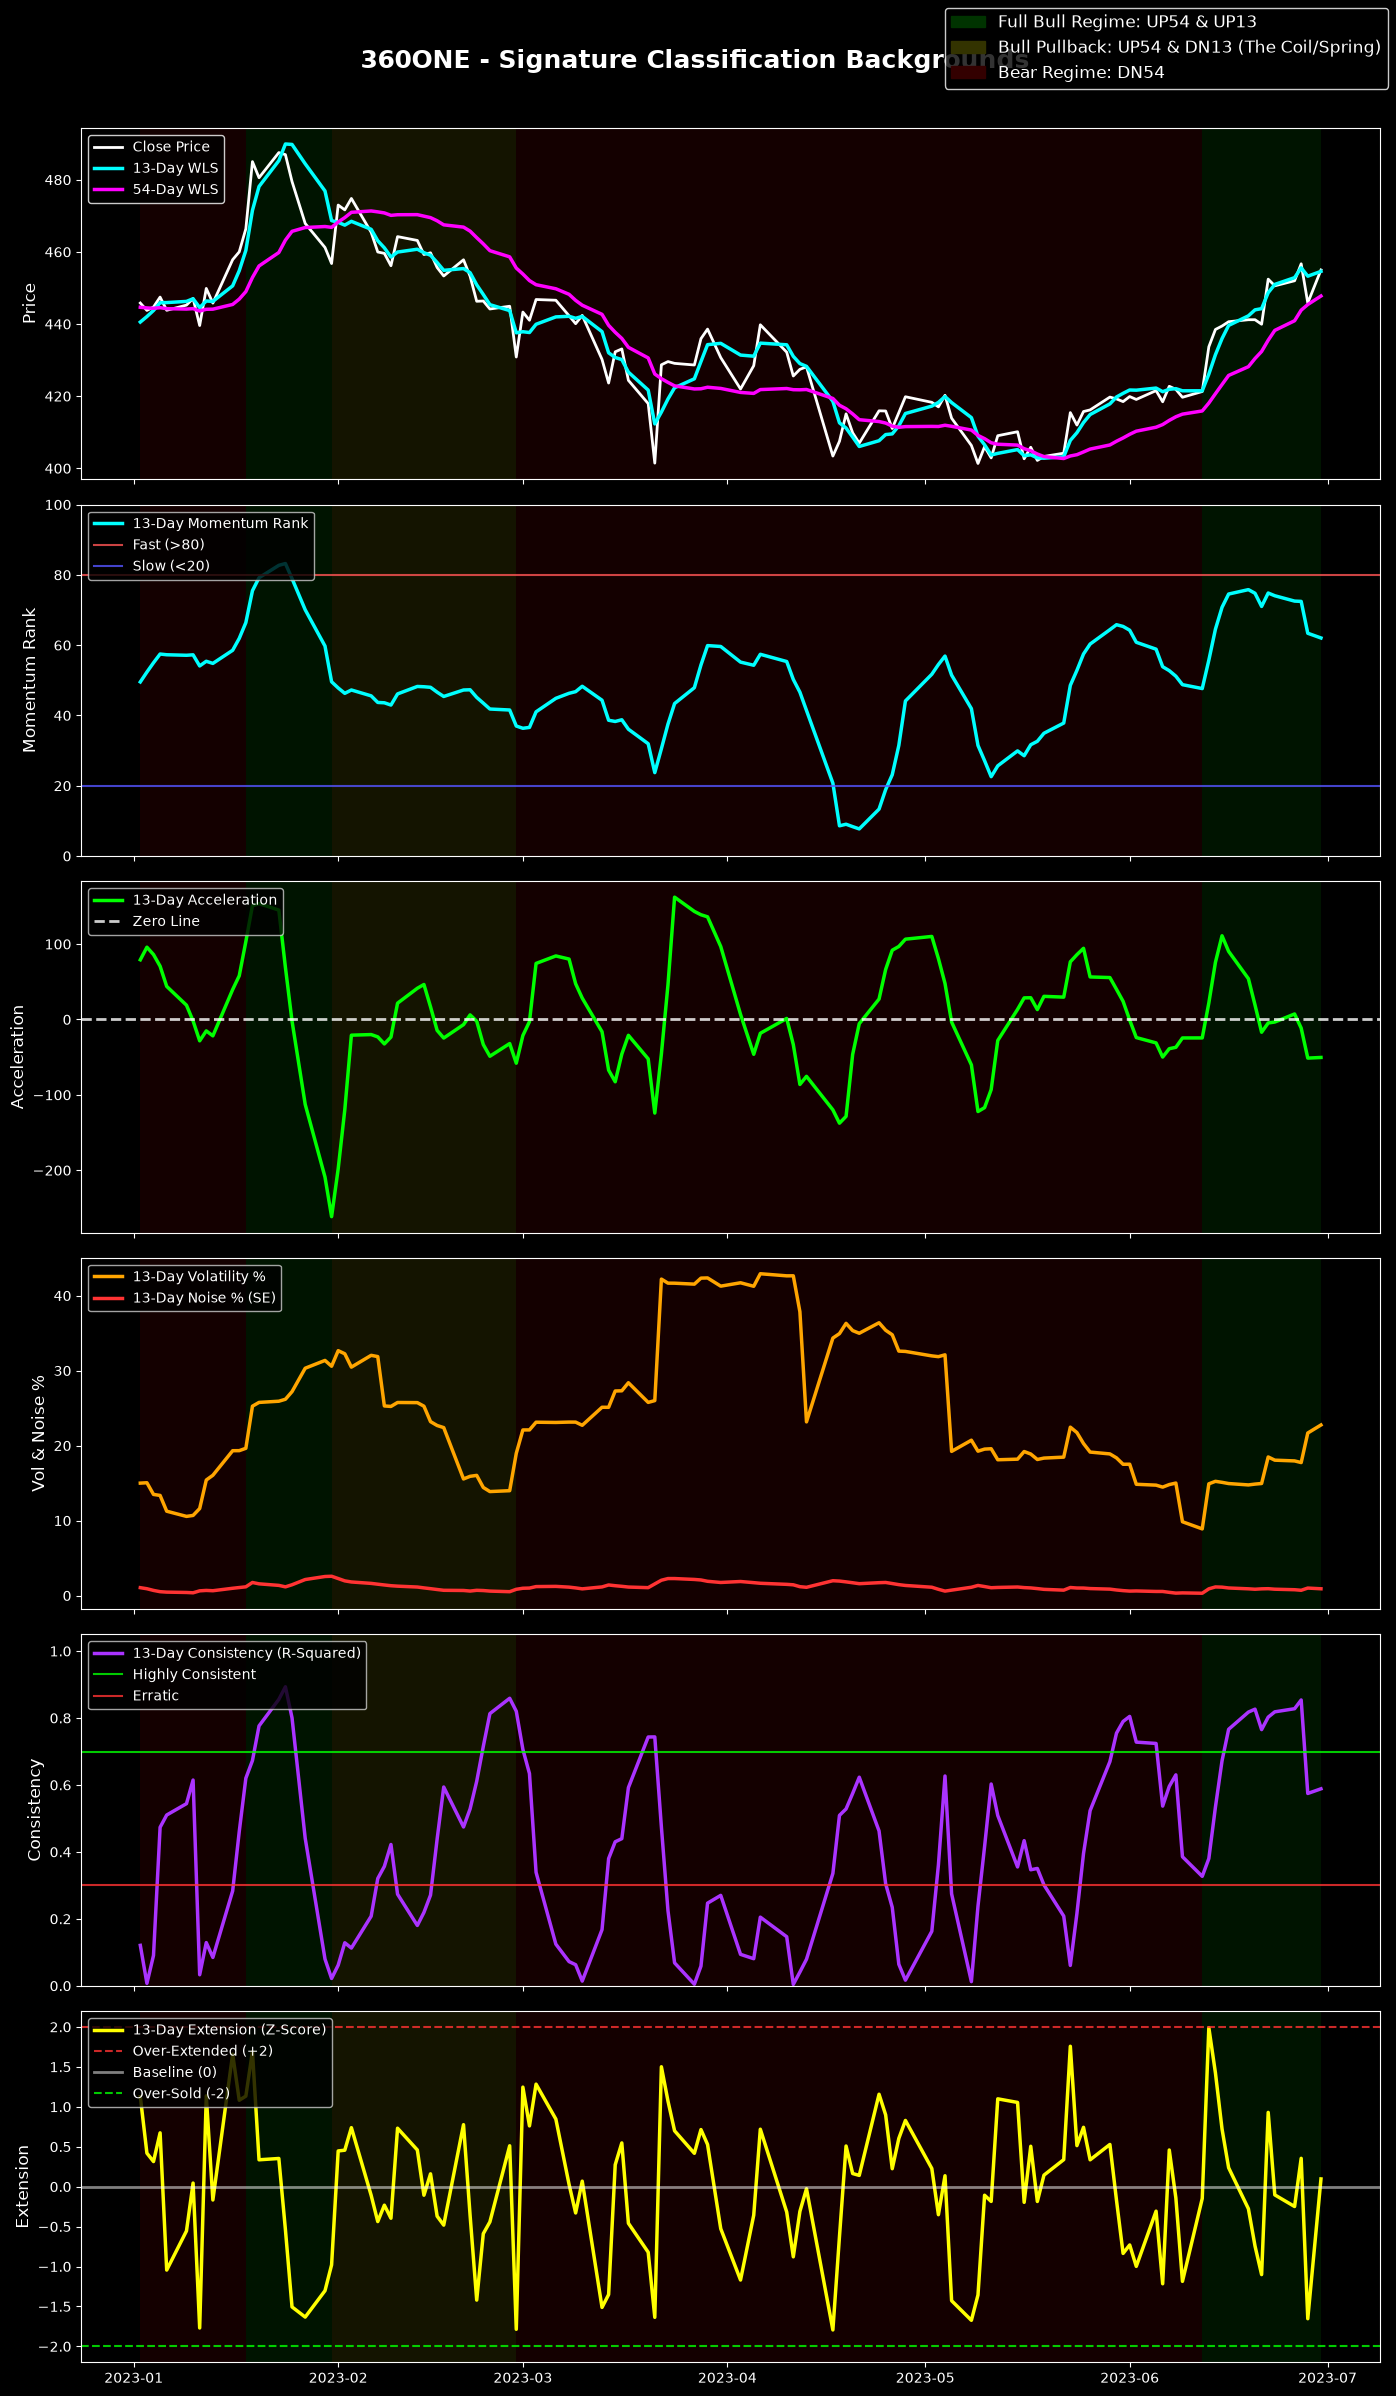


--- 360ONE Last 10 Days Hashes ---
      Date      Close                                                    Hash
2023-06-16 440.649994  [UP13(ris)-UP54(ris)-base-coil-clean-steady(ris)-rest]
2023-06-19 441.200012  [UP13(ris)-UP54(ris)-base-coil-clean-steady(ris)-rest]
2023-06-20 441.200012   [UP13(ris)-UP54(ris)-base-coil-clean-steady(ris)-mid]
2023-06-21 439.950012   [UP13(dec)-UP54(ris)-base-coil-clean-steady(dec)-mid]
2023-06-22 452.450012   [UP13(dec)-UP54(ris)-base-coil-clean-steady(dec)-mid]
2023-06-23 450.600006  [UP13(dec)-UP54(ris)-base-coil-clean-steady(dec)-rest]
2023-06-26 452.000000  [UP13(ris)-UP54(ris)-base-coil-clean-steady(ris)-rest]
2023-06-27 456.700012  [UP13(dec)-UP54(ris)-base-coil-clean-steady(ris)-rest]
2023-06-28 445.850006  [UP13(dec)-UP54(ris)-base-norm-clean-erratic(dec)-mid]
2023-06-30 455.000000 [UP13(dec)-UP54(ris)-base-norm-clean-erratic(dec)-rest]


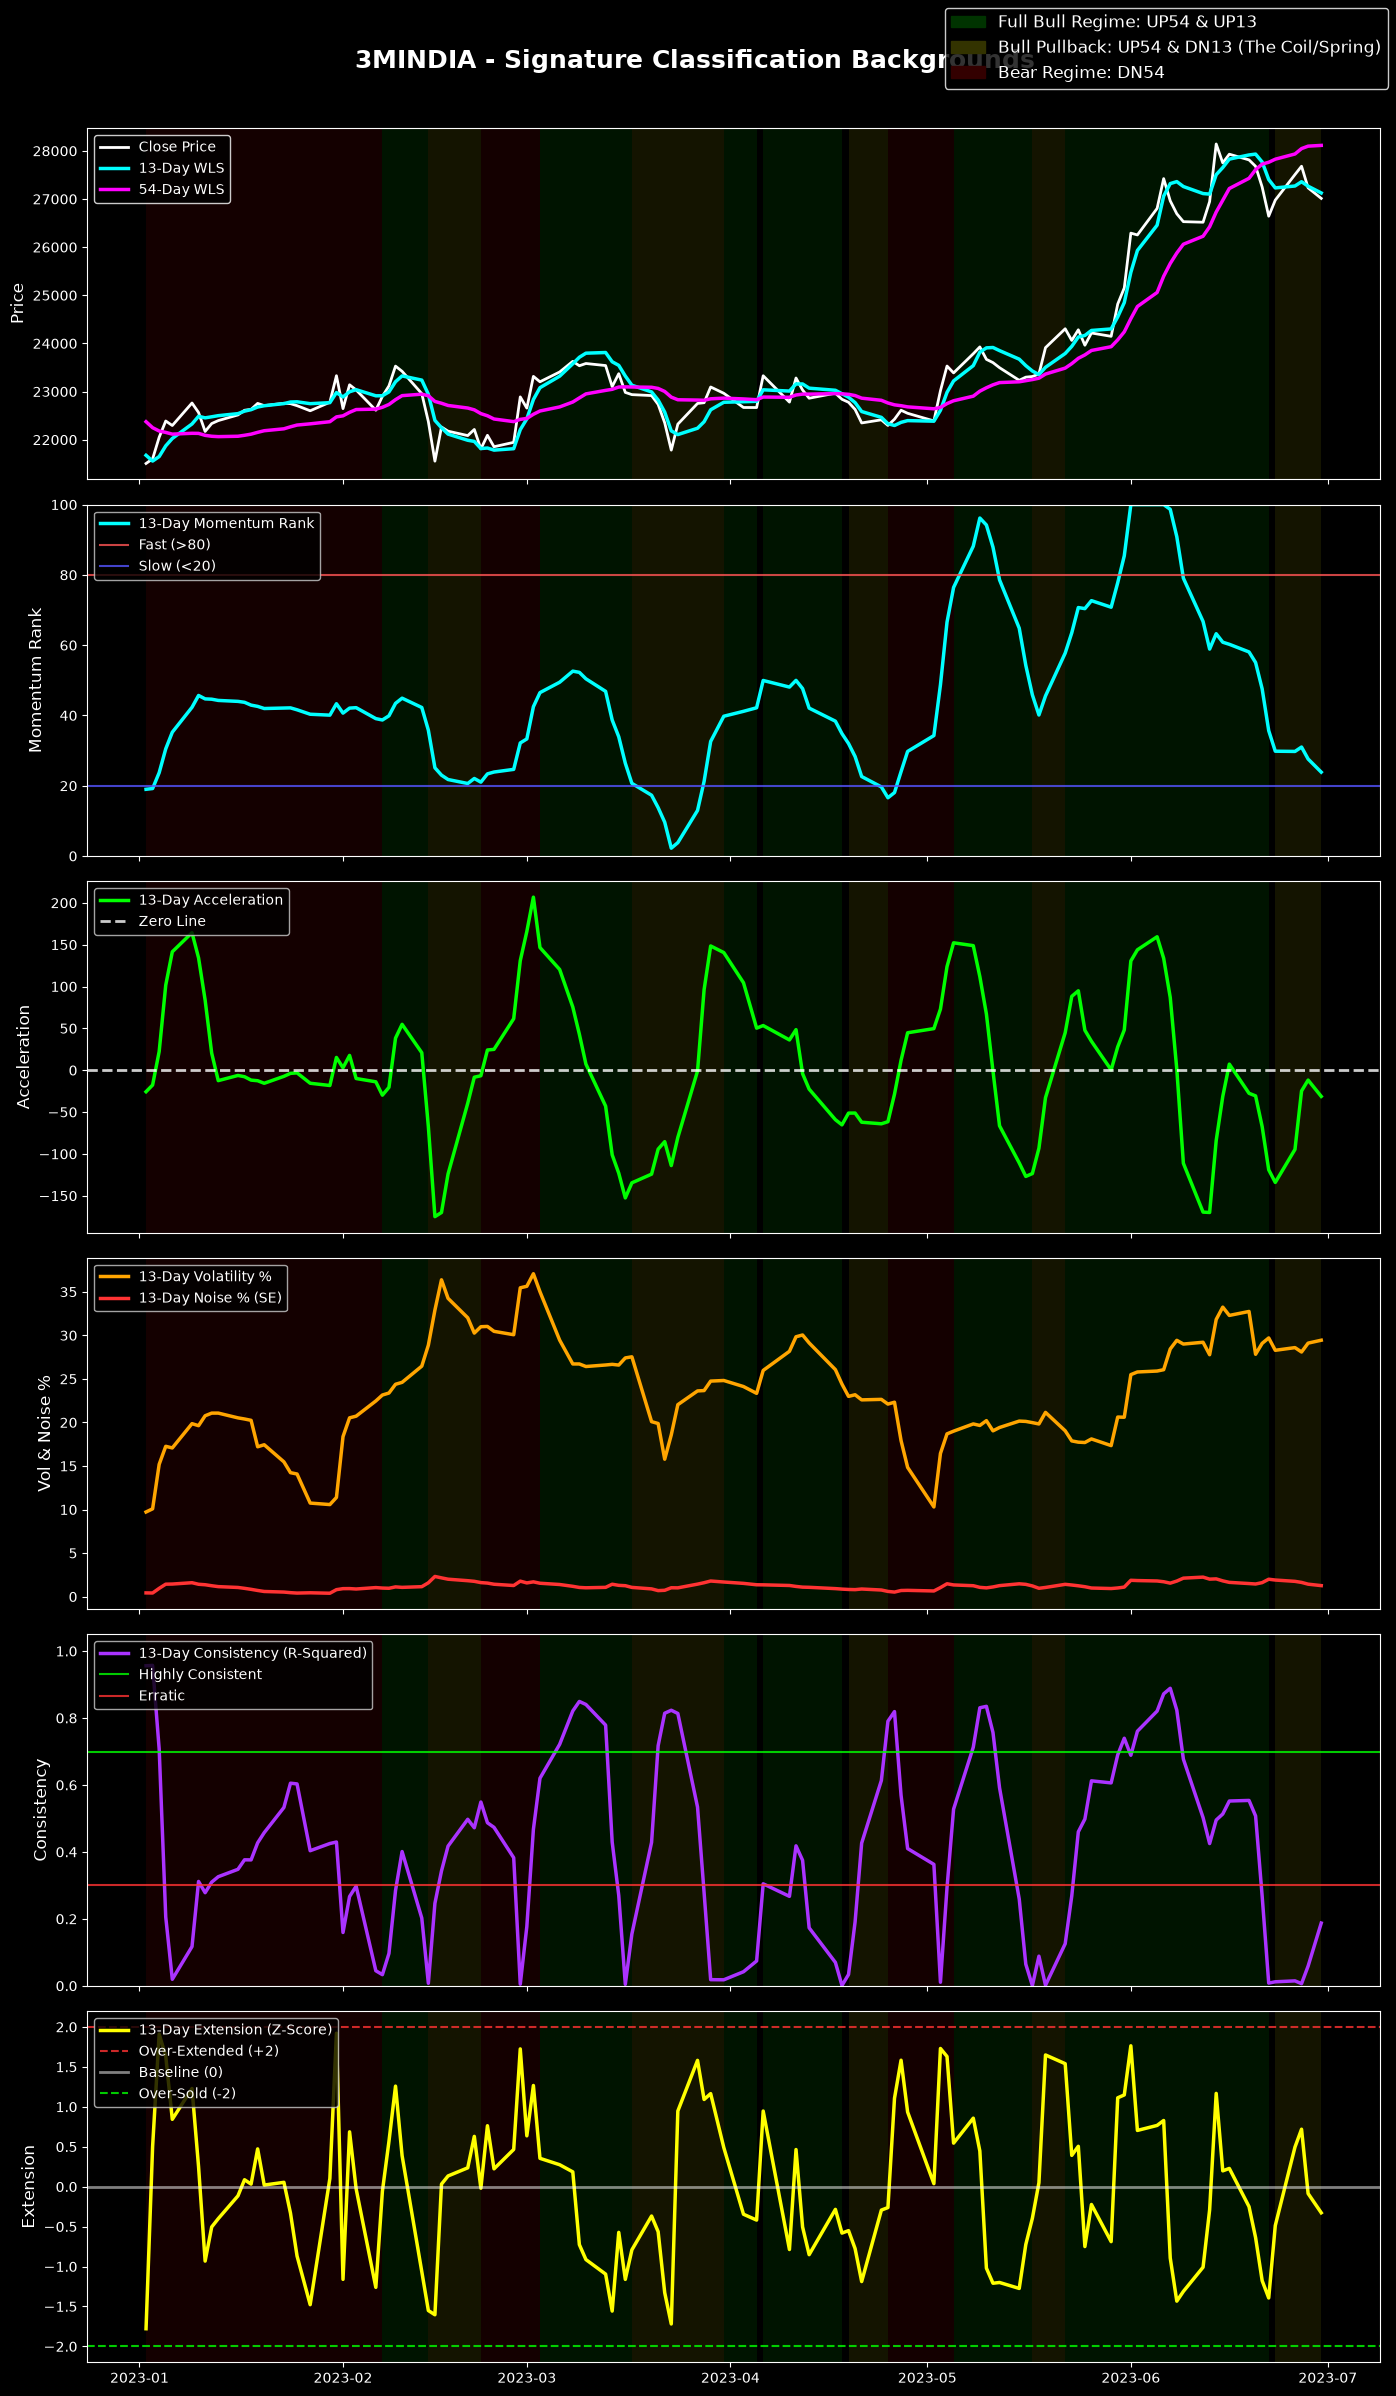


--- 3MINDIA Last 10 Days Hashes ---
      Date        Close                                                    Hash
2023-06-16 27930.650391 [UP13(ris)-UP54(ris)-base-norm-clean-erratic(ris)-rest]
2023-06-19 27812.900391 [UP13(dec)-UP54(ris)-base-norm-clean-erratic(ris)-rest]
2023-06-20 27679.550781  [UP13(dec)-UP54(ris)-base-norm-clean-erratic(dec)-mid]
2023-06-21 27249.699219  [UP13(dec)-UP54(ris)-base-norm-clean-erratic(dec)-mid]
2023-06-22 26642.949219  [UP13(dec)-UP54(dec)-base-norm-clean-erratic(dec)-mid]
2023-06-23 26977.000000 [DN13(dec)-UP54(dec)-base-norm-clean-erratic(dec)-rest]
2023-06-26 27508.000000 [DN13(dec)-UP54(dec)-base-norm-clean-erratic(dec)-rest]
2023-06-27 27680.849609  [DN13(dec)-UP54(dec)-base-norm-clean-erratic(dec)-mid]
2023-06-28 27231.699219 [DN13(dec)-UP54(dec)-base-norm-clean-erratic(ris)-rest]
2023-06-30 27012.699219 [DN13(dec)-UP54(dec)-base-norm-clean-erratic(ris)-rest]


In [3]:
# --- PROCESSING & PLOTTING ---
all_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))[:3]

for file in all_files:
    stock_name = os.path.basename(file).split('.')[0]
    df = pd.read_csv(file)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    try:
        start_idx = df[df['Date'] >= PLOT_START].index[0]
        load_start_idx = max(0, start_idx - WARMUP_DAYS)
        end_idx = df[df['Date'] <= PLOT_END].index[-1]
    except IndexError:
        continue 
        
    df = df.iloc[load_start_idx:end_idx+1].copy()
    
    # Calculate Math
    df['lr_13'], df['slope_13'], df['se_13'], df['r2_13'], df['z_13'] = calc_wls_full(df['Close'], LOOKBACK_SHORT)
    df['lr_54'], df['slope_54'], df['se_54'], df['r2_54'], df['z_54'] = calc_wls_full(df['Close'], LOOKBACK_LONG)
    
    df['accel_13'] = df['slope_13'].diff(ACCEL_LOOKBACK)
    df['accel_54'] = df['slope_54'].diff(ACCEL_LOOKBACK)
    df['slope_13_norm'] = rolling_minmax(df['slope_13'], NORMALIZATION_WINDOW)
    df['vol_13'] = df['Close'].pct_change().rolling(LOOKBACK_SHORT).std() * np.sqrt(252) * 100
    df['r2_accel'] = df['r2_13'].diff(ACCEL_LOOKBACK)
    
    # Generate Hash for every row
    df['Hash'] = df.apply(generate_hash, axis=1)
    df['RegimeColor'] = df['Hash'].apply(assign_regime_color)
    
    # Trim Warmup
    plot_df = df[df['Date'] >= PLOT_START].copy()
    
    # --- PLOTTING ---
    fig, axes = plt.subplots(6, 1, figsize=(14, 24), sharex=True)
    fig.suptitle(f"{stock_name} - Signature Classification Backgrounds", fontsize=18, weight='bold', color='white')
    
    # Paint Backgrounds on all panes
    for ax in axes:
        for i in range(len(plot_df)-1):
            color = plot_df.iloc[i]['RegimeColor']
            if color != 'black':
                ax.axvspan(plot_df.iloc[i]['Date'], plot_df.iloc[i+1]['Date'], color=color, alpha=0.4, linewidth=0)
    
    # Pane 1: Price and Regressions
    axes[0].plot(plot_df['Date'], plot_df['Close'], color='#FFFFFF', linewidth=2, label='Close Price')
    axes[0].plot(plot_df['Date'], plot_df['lr_13'], color='#00FFFF', linewidth=2.5, label='13-Day WLS')
    axes[0].plot(plot_df['Date'], plot_df['lr_54'], color='#FF00FF', linewidth=2.5, label='54-Day WLS')
    axes[0].set_ylabel("Price", fontsize=12)
    axes[0].legend(loc='upper left', frameon=True, facecolor='black', edgecolor='white')
    
    # Pane 2: Normalized Momentum (0-100)
    axes[1].plot(plot_df['Date'], plot_df['slope_13_norm'], color='#00FFFF', linewidth=2.5, label='13-Day Momentum Rank')
    axes[1].axhline(80, color='#FF5555', linestyle='-', linewidth=1.5, alpha=0.8, label='Fast (>80)')
    axes[1].axhline(20, color='#5555FF', linestyle='-', linewidth=1.5, alpha=0.8, label='Slow (<20)')
    axes[1].set_ylabel("Momentum Rank", fontsize=12)
    axes[1].set_ylim(0, 100)
    axes[1].legend(loc='upper left', frameon=True, facecolor='black')
    
    # Pane 3: Acceleration
    axes[2].plot(plot_df['Date'], plot_df['accel_13'], color='#00FF00', linewidth=2.5, label='13-Day Acceleration')
    axes[2].axhline(0, color='white', linestyle='--', linewidth=2, alpha=0.8, label='Zero Line')
    axes[2].set_ylabel("Acceleration", fontsize=12)
    axes[2].legend(loc='upper left', frameon=True, facecolor='black')
    
    # Pane 4: Volatility and Noise
    axes[3].plot(plot_df['Date'], plot_df['vol_13'], color='#FFA500', linewidth=2.5, label='13-Day Volatility %')
    axes[3].plot(plot_df['Date'], plot_df['se_13'], color='#FF3333', linewidth=2.5, label='13-Day Noise % (SE)')
    axes[3].set_ylabel("Vol & Noise %", fontsize=12)
    axes[3].legend(loc='upper left', frameon=True, facecolor='black')
    
    # Pane 5: Consistency (R-Squared)
    axes[4].plot(plot_df['Date'], plot_df['r2_13'], color='#AA33FF', linewidth=2.5, label='13-Day Consistency (R-Squared)')
    axes[4].axhline(0.7, color='#00FF00', linestyle='-', linewidth=1.5, alpha=0.8, label='Highly Consistent')
    axes[4].axhline(0.3, color='#FF3333', linestyle='-', linewidth=1.5, alpha=0.8, label='Erratic')
    axes[4].set_ylabel("Consistency", fontsize=12)
    axes[4].set_ylim(0, 1.05)
    axes[4].legend(loc='upper left', frameon=True, facecolor='black')
    
    # Pane 6: Extension (Z-Score)
    axes[5].plot(plot_df['Date'], plot_df['z_13'], color='#FFFF00', linewidth=2.5, label='13-Day Extension (Z-Score)')
    axes[5].axhline(2, color='#FF3333', linestyle='--', linewidth=1.5, alpha=0.8, label='Over-Extended (+2)')
    axes[5].axhline(0, color='white', linestyle='-', linewidth=2, alpha=0.5, label='Baseline (0)')
    axes[5].axhline(-2, color='#00FF00', linestyle='--', linewidth=1.5, alpha=0.8, label='Over-Sold (-2)')
    axes[5].set_ylabel("Extension", fontsize=12)
    axes[5].legend(loc='upper left', frameon=True, facecolor='black')
    
    # Custom Legend for the Regimes
    green_patch = mpatches.Patch(color='#003300', label='Full Bull Regime: UP54 & UP13')
    yellow_patch = mpatches.Patch(color='#333300', label='Bull Pullback: UP54 & DN13 (The Coil/Spring)')
    red_patch = mpatches.Patch(color='#330000', label='Bear Regime: DN54')
    fig.legend(handles=[green_patch, yellow_patch, red_patch], loc='upper right', facecolor='black', edgecolor='white', fontsize=12)
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    
    # Print the last 10 days of Hash Signatures to console so we can read them
    print(f"\n--- {stock_name} Last 10 Days Hashes ---")
    print(plot_df[['Date', 'Close', 'Hash']].tail(10).to_string(index=False))
